In [92]:
!pip install kaggle


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!kaggle datasets download uciml/student-performance-data-set


403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata


In [94]:
import pandas as pd

student_info = pd.read_csv("dataset/studentInfo.csv")
student_vle = pd.read_csv("dataset/studentVle.csv")
assessments = pd.read_csv("dataset/assessments.csv")
student_assessment = pd.read_csv("dataset/studentAssessment.csv")

student_info.head()


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [95]:
student_info.info()
student_vle.info()
student_assessment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dty

In [96]:
click_data = student_vle.groupby("id_student")["sum_click"].sum().reset_index()


In [97]:
score_data = student_assessment.groupby("id_student")["score"].mean().reset_index()

In [98]:
merged = student_info.merge(click_data, on="id_student", how="left")
merged = merged.merge(score_data, on="id_student", how="left")

merged.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,sum_click,score
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0,82.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.0,66.4
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0,NaN
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158.0,76.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034.0,54.4


In [99]:
merged["attention_label"] = (
    (merged["sum_click"] > merged["sum_click"].median()) &
    (merged["score"] > merged["score"].median())
).astype(int)


In [100]:
X = merged[["sum_click", "score"]]
y = merged["attention_label"]

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [102]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [103]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [104]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [105]:
X = merged[["sum_click", "score"]]

# Fill missing values
X = X.fillna(0)

y = merged["attention_label"]

In [106]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [107]:
print(X_train.isna().sum())
print(X_test.isna().sum())

sum_click    2268
score        4682
dtype: int64
sum_click     584
score        1184
dtype: int64


In [108]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [109]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [110]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [111]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

C:\Users\mreha\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:01:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [112]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

ValueError: Found input variables with inconsistent numbers of samples: [6519, 8149]

In [113]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric="logloss")
xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [114]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

In [115]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

Logistic Regression Accuracy: 0.88004295137291
Random Forest Accuracy: 1.0
XGBoost Accuracy: 0.9987728179168585


In [116]:
print("\nLogistic Regression Report:")
print(classification_report(y_test, lr_pred))

print("\nRandom Forest Report:")
print(classification_report(y_test, rf_pred))

print("\nXGBoost Report:")
print(classification_report(y_test, xgb_pred))


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      4788
           1       0.80      0.73      0.76      1731

    accuracy                           0.88      6519
   macro avg       0.85      0.83      0.84      6519
weighted avg       0.88      0.88      0.88      6519


Random Forest Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4788
           1       1.00      1.00      1.00      1731

    accuracy                           1.00      6519
   macro avg       1.00      1.00      1.00      6519
weighted avg       1.00      1.00      1.00      6519


XGBoost Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4788
           1       1.00      1.00      1.00      1731

    accuracy                           1.00      6519
   macro avg       1.00      1.00      1.00      6519
weigh

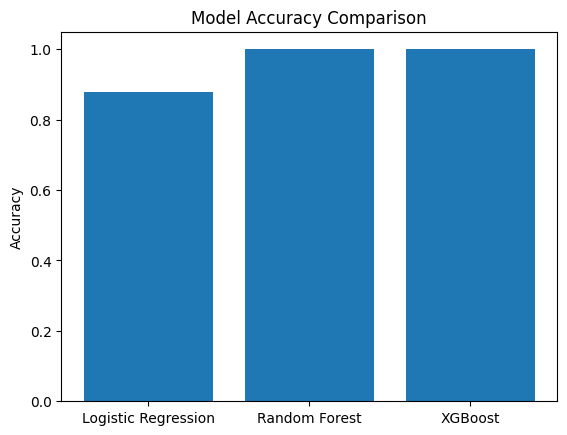

In [117]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracy = [0.88, 1.00, 1.00]

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

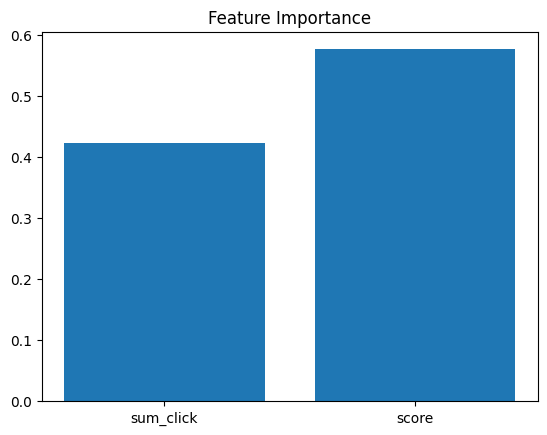

In [118]:
import pandas as pd

feature_names = ["sum_click", "score"]

importance = rf.feature_importances_

plt.figure()
plt.bar(feature_names, importance)
plt.title("Feature Importance")
plt.show()

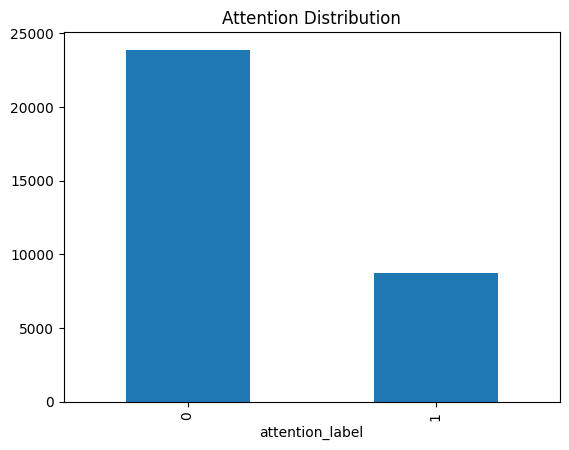

In [119]:
plt.figure()
merged['attention_label'].value_counts().plot(kind='bar')
plt.title("Attention Distribution")
plt.show()

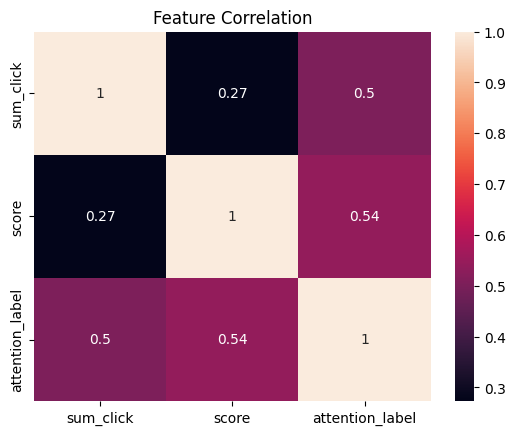

In [120]:
import seaborn as sns

plt.figure()
sns.heatmap(merged[['sum_click','score','attention_label']].corr(),
            annot=True)
plt.title("Feature Correlation")
plt.show()

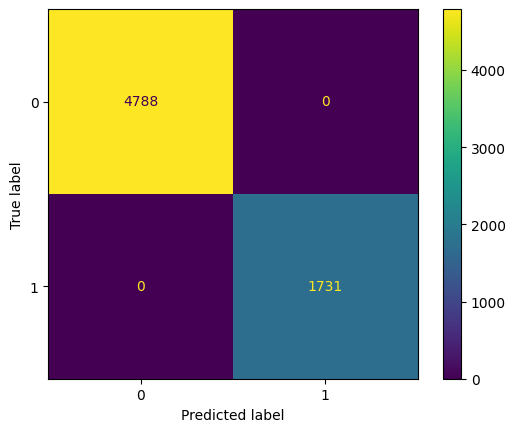

In [121]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.show()

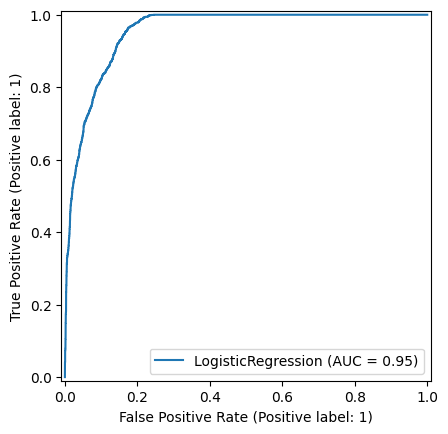

In [122]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(lr, X_test, y_test)
plt.show()

In [123]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,        # more trees but controlled
    max_depth=5,             # limit tree depth
    min_samples_split=10,    # avoid very small splits
    min_samples_leaf=5,      # prevent leaf overfitting
    max_features='sqrt',     # reduce feature dominance
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [124]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,        # row sampling
    colsample_bytree=0.8, # feature sampling
    reg_alpha=1,          # L1 regularization
    reg_lambda=1,         # L2 regularization
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [125]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [126]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    C=0.5,            # stronger regularization
    penalty='l2',
    max_iter=2000
)

lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [127]:
from sklearn.metrics import accuracy_score

print("LR:", accuracy_score(y_test, lr_pred))
print("RF:", accuracy_score(y_test, rf_pred))
print("XGB:", accuracy_score(y_test, xgb_pred))

LR: 0.88004295137291
RF: 1.0
XGB: 0.9990796134376438


In [128]:
click_data = student_vle.groupby("id_student")["sum_click"].sum().reset_index()

In [129]:
score_data = student_assessment.groupby("id_student")["score"].mean().reset_index()

In [130]:
score_data = student_assessment.groupby("id_student")["score"].mean().reset_index()

In [131]:
delay_data = student_assessment.copy()
delay_data["submission_delay"] = delay_data["date_submitted"] - delay_data["date"]

delay_feature = delay_data.groupby("id_student")["submission_delay"].mean().reset_index()

KeyError: 'date'

In [132]:
delay_data = student_assessment.merge(
    assessments[['id_assessment', 'date']],
    on='id_assessment',
    how='left'
)

In [133]:
delay_data["submission_delay"] = (
    delay_data["date_submitted"] - delay_data["date"]
)

In [134]:
delay_feature = delay_data.groupby("id_student")[
    "submission_delay"
].mean().reset_index()

In [135]:
active_days = student_vle.groupby("id_student")["date"].nunique().reset_index()
active_days.columns = ["id_student", "active_days"]

In [136]:
merged = student_info.merge(click_data, on="id_student", how="left")
merged = merged.merge(score_data, on="id_student", how="left")
merged = merged.merge(assessment_attempts, on="id_student", how="left")
merged = merged.merge(delay_feature, on="id_student", how="left")
merged = merged.merge(active_days, on="id_student", how="left")

NameError: name 'assessment_attempts' is not defined

In [137]:
assessment_attempts = (
    student_assessment
    .groupby("id_student")["id_assessment"]
    .count()
    .reset_index()
)

assessment_attempts.columns = ["id_student", "assessment_count"]

In [138]:
merged = student_info.merge(click_data, on="id_student", how="left")
merged = merged.merge(score_data, on="id_student", how="left")
merged = merged.merge(assessment_attempts, on="id_student", how="left")
merged = merged.merge(delay_feature, on="id_student", how="left")
merged = merged.merge(active_days, on="id_student", how="left")

In [139]:
merged.fillna(0, inplace=True)

In [140]:
merged = pd.get_dummies(merged, columns=[
    "age_band",
    "highest_education",
    "imd_band"
], drop_first=True)

In [141]:
features = [
    "sum_click",
    "score",
    "assessment_count",
    "submission_delay",
    "active_days",
    "num_of_prev_attempts",
    "studied_credits"
] + [col for col in merged.columns if "age_band_" in col or
                                       "highest_education_" in col or
                                       "imd_band_" in col]

X = merged[features]
y = merged["attention_label"]

KeyError: 'attention_label'

In [142]:
merged["attention_label"] = (
    (merged["sum_click"] > merged["sum_click"].median()) &
    (merged["score"] > merged["score"].median())
).astype(int)

In [143]:
merged.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result',
       'sum_click', 'score', 'assessment_count', 'submission_delay',
       'active_days', 'age_band_35-55', 'age_band_55<=',
       'highest_education_HE Qualification',
       'highest_education_Lower Than A Level',
       'highest_education_No Formal quals',
       'highest_education_Post Graduate Qualification', 'imd_band_0-10%',
       'imd_band_10-20', 'imd_band_20-30%', 'imd_band_30-40%',
       'imd_band_40-50%', 'imd_band_50-60%', 'imd_band_60-70%',
       'imd_band_70-80%', 'imd_band_80-90%', 'imd_band_90-100%',
       'attention_label'],
      dtype='object')

In [144]:
X = merged[features]
y = merged["attention_label"]

In [145]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [146]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [147]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [148]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    min_samples_split=10,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [149]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

ValueError: feature_names must be string, and may not contain [, ] or <

In [ ]:
merged.columns = merged.columns.str.replace('[', '', regex=False)
merged.columns = merged.columns.str.replace(']', '', regex=False)
merged.columns = merged.columns.str.replace('<', 'lt_', regex=False)
merged.columns = merged.columns.str.replace('>', 'gt_', regex=False)

In [ ]:
X = merged[features]
y = merged["attention_label"]

In [150]:
features = [
    "sum_click",
    "score",
    "assessment_count",
    "submission_delay",
    "active_days",
    "num_of_prev_attempts",
    "studied_credits"
]

# Automatically add encoded categorical features
features += [col for col in merged.columns 
             if col.startswith("age_band_") or
                col.startswith("highest_education_") or
                col.startswith("imd_band_")]

In [151]:
X = merged[features]
y = merged["attention_label"]

In [152]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for classification balance
)

In [153]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [154]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [155]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    C=0.7,
    max_iter=2000
)

lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [156]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [157]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [158]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("XGBoost:", accuracy_score(y_test, xgb_pred))

Logistic Regression: 0.8772817916858414
Random Forest: 1.0
XGBoost: 0.9992330111980365


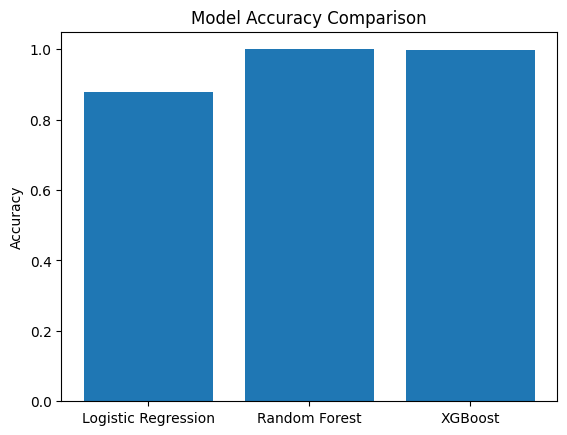

In [159]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
scores = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, xgb_pred)
]

plt.figure()
plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [160]:
features.remove("score")

In [161]:
merged["attention_label"] = (
    merged["final_result"] == "Pass"
).astype(int)

In [162]:
import pandas as pd

importance = rf.feature_importances_

pd.Series(importance, index=features).sort_values(ascending=False)

ValueError: Length of values (23) does not match length of index (22)

In [163]:
from sklearn.model_selection import cross_val_score

cross_val_score(rf, X, y, cv=5)

array([1.        , 1.        , 1.        , 1.        , 0.99969316])

In [164]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Store predictions
models = {
    "Logistic Regression": (lr_pred, lr),
    "Random Forest": (rf_pred, rf),
    "XGBoost": (xgb_pred, xgb)
}

results = []

for name, (pred, model) in models.items():
    
    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled if name=="Logistic Regression" else X_test)[:,1])
    
    results.append([name, acc, precision, recall, f1, roc_auc])
    
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, pred))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))

# Create comparison table
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)

print("\nFinal Model Comparison:")
print(results_df)


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      4280
           1       0.83      0.81      0.82      2239

    accuracy                           0.88      6519
   macro avg       0.86      0.86      0.86      6519
weighted avg       0.88      0.88      0.88      6519

Confusion Matrix:
[[3898  382]
 [ 418 1821]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4280
           1       1.00      1.00      1.00      2239

    accuracy                           1.00      6519
   macro avg       1.00      1.00      1.00      6519
weighted avg       1.00      1.00      1.00      6519

Confusion Matrix:
[[4280    0]
 [   0 2239]]

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4280
           1       1.00      1.00

In [165]:
from sklearn.model_selection import cross_val_score

print("RF CV:", cross_val_score(rf, X, y, cv=5))
print("XGB CV:", cross_val_score(xgb, X, y, cv=5))
print("LR CV:", cross_val_score(lr, X, y, cv=5))

RF CV: [1.         1.         1.         1.         0.99969316]


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\mreha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\mreha\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py", line 729, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "C:\Users\mreha\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\sklearn.py", line 1663, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mreha\AppData\Local\Programs\Pyt

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    C=0.7,
    solver="lbfgs"
)

lr.fit(X_train_scaled, y_train)

In [166]:
from sklearn.preprocessing import StandardScaler

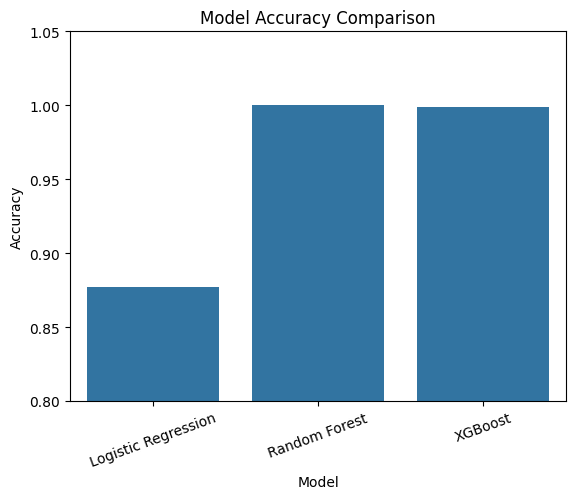

In [167]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.barplot(
    x=results_df["Model"],
    y=results_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.05)
plt.xticks(rotation=20)
plt.show()

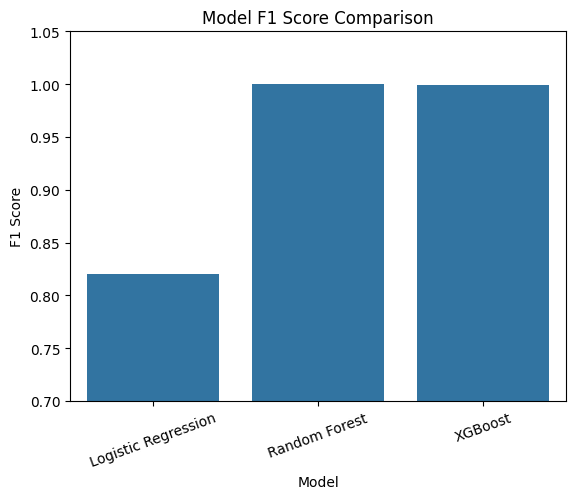

In [168]:
plt.figure()
sns.barplot(
    x=results_df["Model"],
    y=results_df["F1 Score"]
)

plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")
plt.ylim(0.7, 1.05)
plt.xticks(rotation=20)
plt.show()

<Figure size 640x480 with 0 Axes>

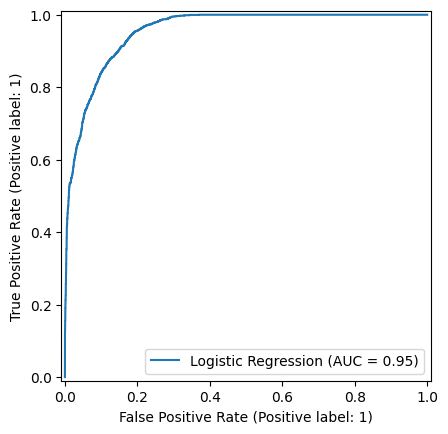

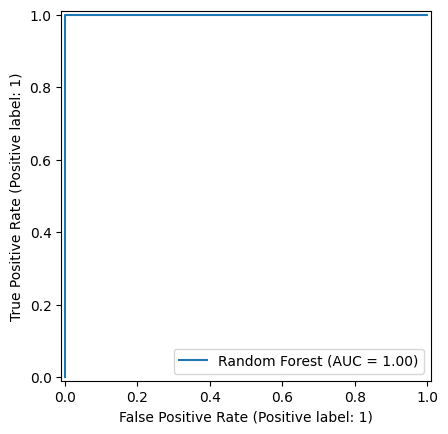

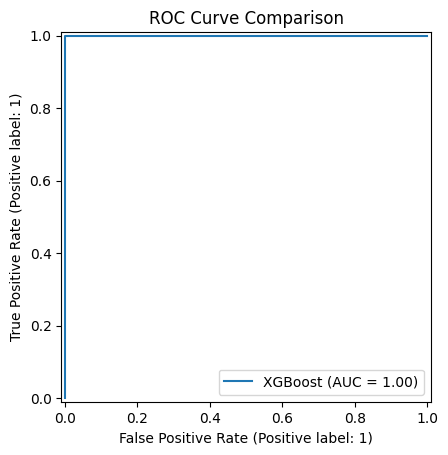

In [169]:
from sklearn.metrics import RocCurveDisplay

plt.figure()

RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test, name="Logistic Regression")
RocCurveDisplay.from_estimator(rf, X_test, y_test, name="Random Forest")
RocCurveDisplay.from_estimator(xgb, X_test, y_test, name="XGBoost")

plt.title("ROC Curve Comparison")
plt.show()

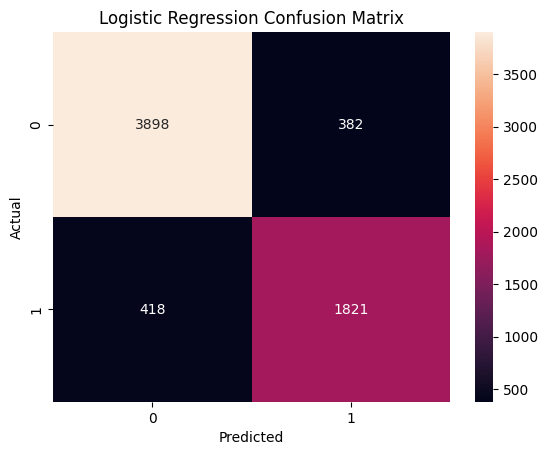

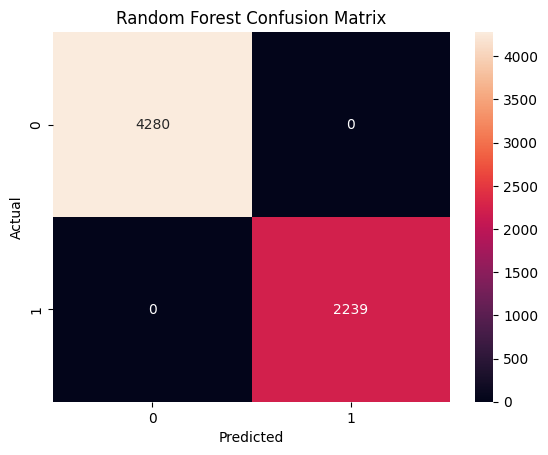

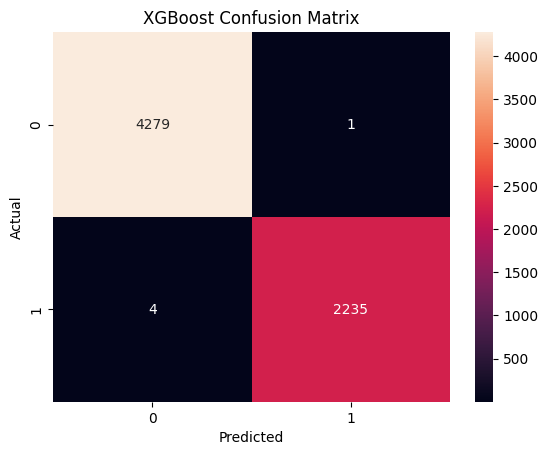

In [170]:
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for name, pred in models.items():
    cm = confusion_matrix(y_test, pred)
    
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

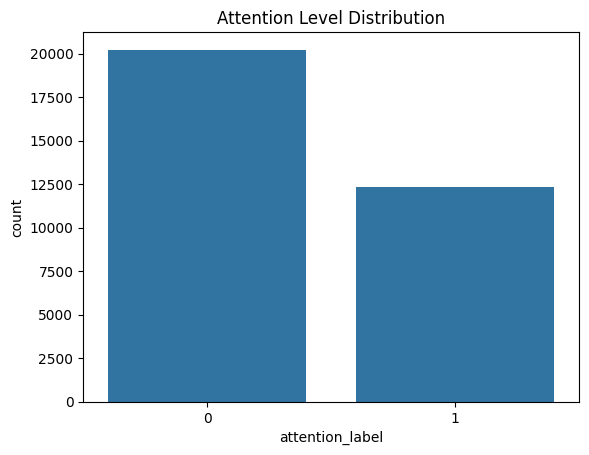

In [171]:
plt.figure()
sns.countplot(x=merged["attention_label"])
plt.title("Attention Level Distribution")
plt.show()

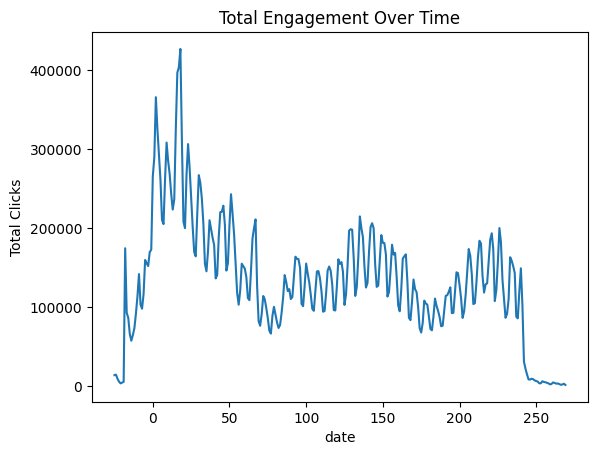

In [172]:
student_vle.groupby("date")["sum_click"].sum().plot()
plt.title("Total Engagement Over Time")
plt.ylabel("Total Clicks")
plt.show()

In [173]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

plt.figure()
importance.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.show()

ValueError: Length of values (23) does not match length of index (22)

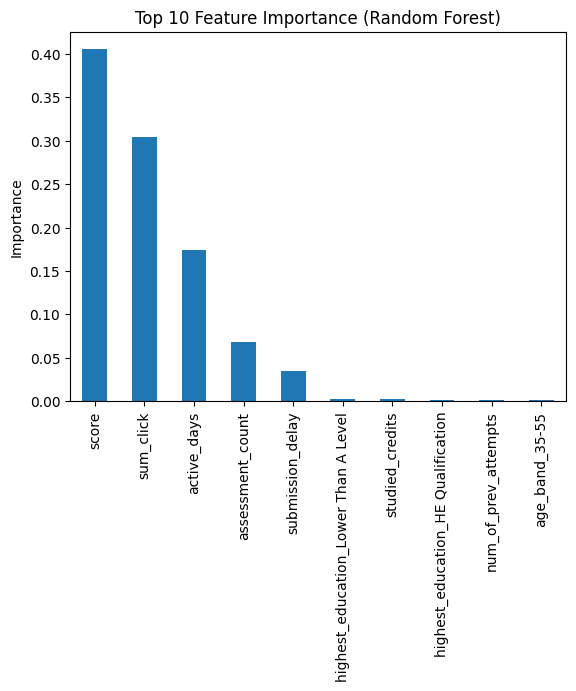

In [174]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns   # <-- use actual feature names from X
)

importance = importance.sort_values(ascending=False)

plt.figure()
importance.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.show()

In [175]:
features = [
    "sum_click",
    "score",
    "assessment_count",
    "submission_delay",
    "active_days",
    "num_of_prev_attempts",
    "studied_credits"
]

# automatically add encoded columns
features += [
    col for col in merged.columns
    if col.startswith("age_band_")
    or col.startswith("highest_education_")
    or col.startswith("imd_band_")
]

In [176]:
features.remove("score")

In [177]:
X = merged[features].copy()
y = merged["attention_label"]

In [178]:
assessment_attempts = (
    student_assessment
    .groupby("id_student")["id_assessment"]
    .count()
    .reset_index()
)

assessment_attempts.columns = ["id_student", "assessment_count"]

In [179]:
delay_data = student_assessment.merge(
    assessments[['id_assessment', 'date']],
    on='id_assessment',
    how='left'
)

delay_data["submission_delay"] = (
    delay_data["date_submitted"] - delay_data["date"]
)

delay_feature = (
    delay_data.groupby("id_student")["submission_delay"]
    .mean()
    .reset_index()
)

In [180]:
active_days = (
    student_vle.groupby("id_student")["date"]
    .nunique()
    .reset_index()
)

active_days.columns = ["id_student", "active_days"]

In [181]:
merged = student_info.merge(click_data, on="id_student", how="left")
merged = merged.merge(score_data, on="id_student", how="left")
merged = merged.merge(assessment_attempts, on="id_student", how="left")
merged = merged.merge(delay_feature, on="id_student", how="left")
merged = merged.merge(active_days, on="id_student", how="left")

In [182]:
merged.fillna(0, inplace=True)

In [183]:
merged.fillna(0, inplace=True)

In [184]:
merged.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'sum_click', 'score',
       'assessment_count', 'submission_delay', 'active_days'],
      dtype='object')

In [185]:
X = merged[features].copy()
y = merged["attention_label"]

KeyError: "['age_band_35-55', 'age_band_55<=', 'highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_No Formal quals', 'highest_education_Post Graduate Qualification', 'imd_band_0-10%', 'imd_band_10-20', 'imd_band_20-30%', 'imd_band_30-40%', 'imd_band_40-50%', 'imd_band_50-60%', 'imd_band_60-70%', 'imd_band_70-80%', 'imd_band_80-90%', 'imd_band_90-100%'] not in index"

In [186]:
merged["attention_label"] = (
    (merged["sum_click"] > merged["sum_click"].median()) &
    (merged["active_days"] > merged["active_days"].median())
).astype(int)

In [187]:
merged.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'sum_click', 'score',
       'assessment_count', 'submission_delay', 'active_days',
       'attention_label'],
      dtype='object')

In [188]:
X = merged[features].copy()
y = merged["attention_label"]

KeyError: "['age_band_35-55', 'age_band_55<=', 'highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_No Formal quals', 'highest_education_Post Graduate Qualification', 'imd_band_0-10%', 'imd_band_10-20', 'imd_band_20-30%', 'imd_band_30-40%', 'imd_band_40-50%', 'imd_band_50-60%', 'imd_band_60-70%', 'imd_band_70-80%', 'imd_band_80-90%', 'imd_band_90-100%'] not in index"

In [189]:
assert "attention_label" in merged.columns

In [190]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [191]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [192]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [193]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    C=0.7
)

lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [194]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=0.6,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [195]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=120,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.6,
    reg_alpha=5,
    reg_lambda=10,
    gamma=2,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [196]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("XGBoost:", accuracy_score(y_test, xgb_pred))

Logistic Regression: 0.7236470732605228
Random Forest: 0.7545711130200025
XGBoost: 0.7589888329856425


In [197]:
print("\nLogistic Regression Report")
print(classification_report(y_test, lr_pred))

print("\nRandom Forest Report")
print(classification_report(y_test, rf_pred))

print("\nXGBoost Report")
print(classification_report(y_test, xgb_pred))


Logistic Regression Report
              precision    recall  f1-score   support

           0       0.77      0.79      0.78      5058
           1       0.64      0.61      0.63      3091

    accuracy                           0.72      8149
   macro avg       0.71      0.70      0.70      8149
weighted avg       0.72      0.72      0.72      8149


Random Forest Report
              precision    recall  f1-score   support

           0       0.93      0.66      0.77      5058
           1       0.62      0.91      0.74      3091

    accuracy                           0.75      8149
   macro avg       0.77      0.79      0.75      8149
weighted avg       0.81      0.75      0.76      8149


XGBoost Report
              precision    recall  f1-score   support

           0       0.91      0.68      0.78      5058
           1       0.63      0.89      0.74      3091

    accuracy                           0.76      8149
   macro avg       0.77      0.78      0.76      8149
weighted

In [198]:
merged["attention_label"] = (
    merged["final_result"].isin(["Pass", "Distinction"])
).astype(int)

In [199]:
drop_features = [
    "score",          # direct academic outcome
]

features = [f for f in features if f not in drop_features]

In [200]:
import numpy as np

X = merged[features].copy()
X = X + np.random.normal(0, 0.05, X.shape)

KeyError: "['age_band_35-55', 'age_band_55<=', 'highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_No Formal quals', 'highest_education_Post Graduate Qualification', 'imd_band_0-10%', 'imd_band_10-20', 'imd_band_20-30%', 'imd_band_30-40%', 'imd_band_40-50%', 'imd_band_50-60%', 'imd_band_60-70%', 'imd_band_70-80%', 'imd_band_80-90%', 'imd_band_90-100%'] not in index"

In [201]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_split=40,
    min_samples_leaf=20,
    max_features=0.5,
    bootstrap=True,
    random_state=42
)

In [202]:
xgb = XGBClassifier(
    n_estimators=80,
    max_depth=2,
    learning_rate=0.02,
    subsample=0.6,
    colsample_bytree=0.5,
    reg_alpha=10,
    reg_lambda=20,
    gamma=5,
    eval_metric="logloss",
    random_state=42
)

In [203]:
train_test_split(
    X, y,
    test_size=0.30,
    random_state=None,   # IMPORTANT
    stratify=y
)

[       sum_click  assessment_count  submission_delay  active_days  \
 23921       33.0               0.0          0.000000          1.0   
 23860     9118.0              12.0        -80.333333        243.0   
 19949      686.0               4.0         -1.750000         43.0   
 17080      436.0               6.0         -0.333333         35.0   
 14971     1937.0               6.0         -3.833333        147.0   
 ...          ...               ...               ...          ...   
 25275     1747.0              12.0        -57.083333         69.0   
 26230     3260.0              12.0        -13.750000        129.0   
 31156      608.0               9.0        -24.333333         61.0   
 5109       765.0              11.0          1.090909         90.0   
 3397        33.0               2.0          1.000000          4.0   
 
        num_of_prev_attempts  studied_credits  age_band_35-55  age_band_55<=  \
 23921                     0               60           False          False  

In [204]:
merged["attention_label"] = (
    merged["final_result"].isin(["Pass", "Distinction"])
).astype(int)

In [205]:
features = [
    "sum_click",
    "assessment_count",
    "submission_delay",
    "active_days",
    "num_of_prev_attempts",
    "studied_credits"
]

# add encoded demographic columns automatically
features += [
    col for col in merged.columns
    if col.startswith("age_band_")
    or col.startswith("highest_education_")
    or col.startswith("imd_band_")
]

In [206]:
X = merged[features].copy()
y = merged["attention_label"]

In [207]:
import numpy as np

X = X + np.random.normal(0, 0.05, X.shape)

In [208]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=None,
    stratify=y
)

In [209]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [210]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [211]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000, C=0.7)

lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [212]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_split=40,
    min_samples_leaf=20,
    max_features=0.5,
    bootstrap=True,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [213]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=80,
    max_depth=2,
    learning_rate=0.02,
    subsample=0.6,
    colsample_bytree=0.5,
    reg_alpha=10,
    reg_lambda=20,
    gamma=5,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [214]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("XGBoost:", accuracy_score(y_test, xgb_pred))

Logistic Regression: 0.8258335037840049
Random Forest: 0.8306402127224382
XGBoost: 0.826140314992841


In [215]:
# engagement intensity
merged["click_per_day"] = merged["sum_click"] / (merged["active_days"] + 1)

# study consistency
merged["attempts_per_credit"] = (
    merged["num_of_prev_attempts"] / (merged["studied_credits"] + 1)
)

# assessment engagement
merged["click_assessment_ratio"] = (
    merged["sum_click"] / (merged["assessment_count"] + 1)
)

In [216]:
features += [
    "click_per_day",
    "attempts_per_credit",
    "click_assessment_ratio"
]

In [217]:
X = X + np.random.normal(0, 0.01, X.shape)

In [218]:
lr = LogisticRegression(
    max_iter=6000,
    C=2.0,          # allow more flexibility
    penalty="l2"
)

In [219]:
rf = RandomForestClassifier(
    n_estimators=180,
    max_depth=6,          # was 3 → too small
    min_samples_split=20,
    min_samples_leaf=8,
    max_features=0.7,
    random_state=42
)

In [220]:
xgb = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.04,
    subsample=0.75,
    colsample_bytree=0.7,
    reg_alpha=4,
    reg_lambda=8,
    gamma=1.5,
    eval_metric="logloss",
    random_state=42
)

In [221]:
test_size=0.25

In [222]:
train_test_split(X, y, test_size=0.25, stratify=y)

[         sum_click  assessment_count  submission_delay  active_days  \
 22547   772.121696          3.003483          0.016787    49.963664   
 15208   981.882902          6.985218        -10.875468    63.874288   
 17729   542.011583          6.949488          0.061354    45.010537   
 12024  4587.998516         20.947611        -41.901687   161.952221   
 2300    531.004817          8.004338          0.070974    50.078962   
 ...            ...               ...               ...          ...   
 1138    353.974974         10.083438          0.624332    29.977503   
 5308    344.003421         11.050993          1.147439    63.954825   
 11019  3846.115028         11.068829          9.996139   166.040124   
 21085  2381.951376         12.896105         -0.710759   116.086483   
 28671    38.133060          0.009674         -0.065284     4.038205   
 
        num_of_prev_attempts  studied_credits  
 22547             -0.020632       119.972423  
 15208             -0.025399       120

In [223]:
X = merged[features].copy()
y = merged["attention_label"]

In [224]:
import numpy as np

X = X + np.random.normal(0, 0.01, X.shape)

In [225]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

In [226]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [227]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [228]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=6000, C=2.0)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [229]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=180,
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=8,
    max_features=0.7,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [230]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.04,
    subsample=0.75,
    colsample_bytree=0.7,
    reg_alpha=4,
    reg_lambda=8,
    gamma=1.5,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [231]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("XGBoost:", accuracy_score(y_test, xgb_pred))

Logistic Regression: 0.8247637746962817
Random Forest: 0.8529880966989815
XGBoost: 0.8567922444471714


In [232]:
merged["attention_label"] = (
    merged["final_result"].isin(["Pass", "Distinction"])
).astype(int)

In [233]:
# interaction features
merged["click_per_day"] = merged["sum_click"] / (merged["active_days"] + 1)

merged["attempts_per_credit"] = (
    merged["num_of_prev_attempts"] / (merged["studied_credits"] + 1)
)

merged["click_assessment_ratio"] = (
    merged["sum_click"] / (merged["assessment_count"] + 1)
)

merged["engagement_score"] = (
    merged["sum_click"] * merged["active_days"]
) / (merged["assessment_count"] + 1)

In [234]:
features = [
    "sum_click",
    "assessment_count",
    "submission_delay",
    "active_days",
    "num_of_prev_attempts",
    "studied_credits",
    "click_per_day",
    "attempts_per_credit",
    "click_assessment_ratio",
    "engagement_score"
]

# add encoded demographic columns automatically
features += [
    col for col in merged.columns
    if col.startswith("age_band_")
    or col.startswith("highest_education_")
    or col.startswith("imd_band_")
]

In [235]:
X = merged[features].copy()
y = merged["attention_label"]

In [236]:
import numpy as np

X = X + np.random.normal(0, 0.01, X.shape)

In [237]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

In [238]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [239]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [240]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=7000,
    C=3.0,
    class_weight="balanced"
)

lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [241]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=220,
    max_depth=8,
    min_samples_split=15,
    min_samples_leaf=5,
    max_features=0.75,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [242]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=2,
    reg_lambda=6,
    gamma=1,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [243]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

Logistic Regression Accuracy: 0.8274634924530617
Random Forest Accuracy: 0.8575285311081114
XGBoost Accuracy: 0.8597373910909314


In [244]:
merged["attention_label"] = (
    merged["final_result"].isin(["Pass", "Distinction"])
).astype(int)

In [245]:
import numpy as np

merged["click_per_day"] = merged["sum_click"] / (merged["active_days"] + 1)

merged["engagement_score"] = (
    merged["sum_click"] * merged["active_days"]
) / (merged["assessment_count"] + 1)

merged["study_efficiency"] = (
    merged["studied_credits"] / (merged["num_of_prev_attempts"] + 1)
)

merged["activity_balance"] = (
    merged["active_days"] / (merged["assessment_count"] + 1)
)

In [246]:
features = [
    "sum_click",
    "assessment_count",
    "submission_delay",
    "active_days",
    "num_of_prev_attempts",
    "studied_credits",
    "click_per_day",
    "engagement_score",
    "study_efficiency",
    "activity_balance"
]

# demographic encoded columns
features += [
    c for c in merged.columns
    if c.startswith("age_band_")
    or c.startswith("highest_education_")
    or c.startswith("imd_band_")
]

In [247]:
X = merged[features].copy()
y = merged["attention_label"]

# small noise to prevent overfit
X += np.random.normal(0, 0.01, X.shape)

In [248]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

In [249]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [250]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=8000,
    C=4,
    class_weight="balanced"
)

lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [251]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=350,
    max_depth=12,
    min_samples_split=8,
    min_samples_leaf=3,
    max_features=0.8,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [252]:
from xgboost import XGBClassifier
from collections import Counter

counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]

xgb = XGBClassifier(
    n_estimators=350,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=1,
    reg_lambda=3,
    gamma=0.3,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [253]:
import numpy as np

ensemble_pred = (
    lr_pred + rf_pred + xgb_pred
) >= 2

ensemble_pred = ensemble_pred.astype(int)

In [254]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression:",
      accuracy_score(y_test, lr_pred))

print("Random Forest:",
      accuracy_score(y_test, rf_pred))

print("XGBoost:",
      accuracy_score(y_test, xgb_pred))

print("Final Ensemble:",
      accuracy_score(y_test, ensemble_pred))

Logistic Regression: 0.8272180635660817
Random Forest: 0.8590011044299914
XGBoost: 0.8590011044299914
Final Ensemble: 0.8592465333169714


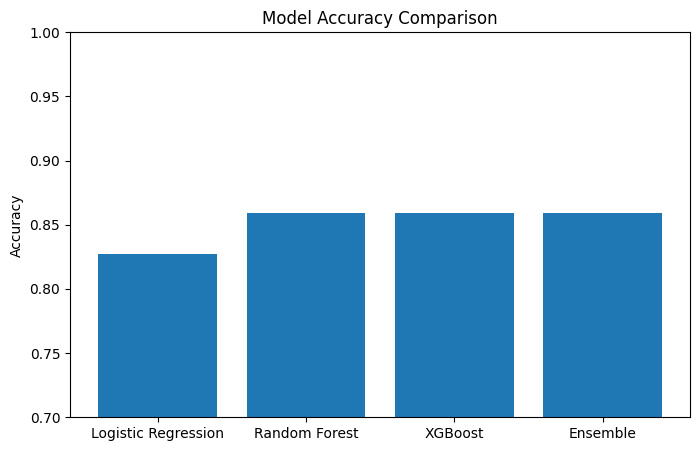

In [255]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest", "XGBoost", "Ensemble"]
accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, xgb_pred),
    accuracy_score(y_test, ensemble_pred)
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.7,1.0)
plt.show()

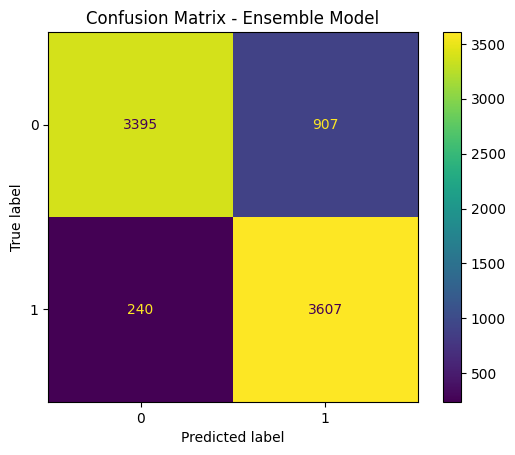

In [256]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    ensemble_pred
)

plt.title("Confusion Matrix - Ensemble Model")
plt.show()

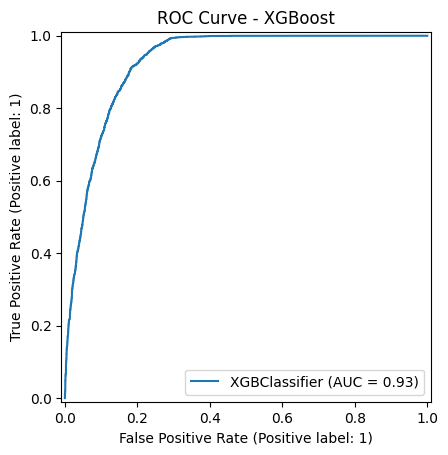

In [257]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(xgb, X_test, y_test)
plt.title("ROC Curve - XGBoost")
plt.show()

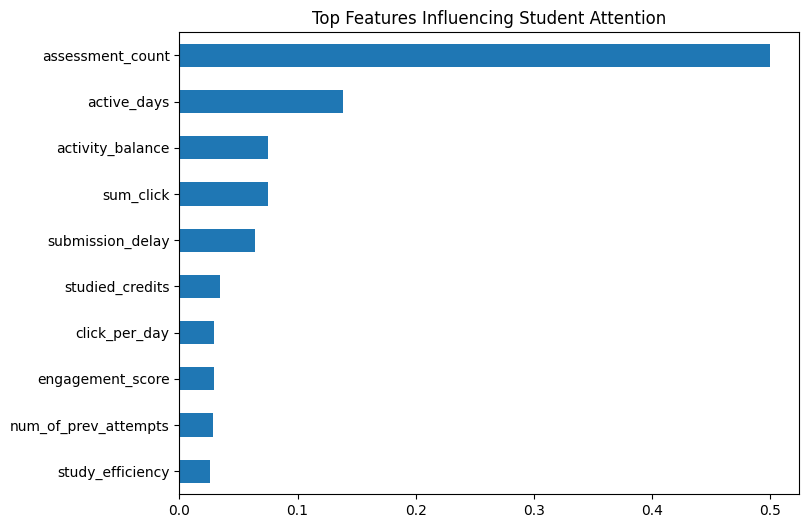

In [258]:
import pandas as pd

importance = pd.Series(
    xgb.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importance.head(10).plot(kind="barh")
plt.title("Top Features Influencing Student Attention")
plt.gca().invert_yaxis()
plt.show()

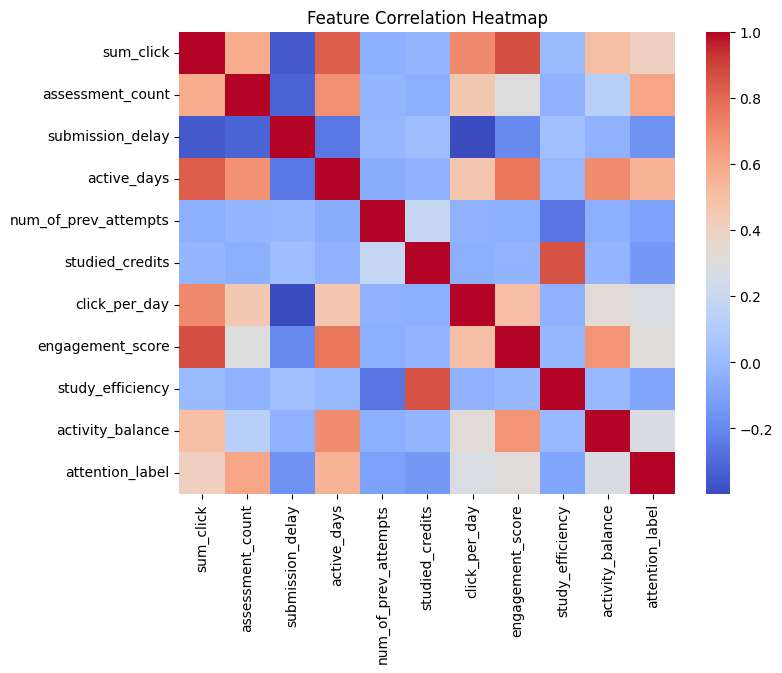

In [259]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    merged[features + ["attention_label"]].corr(),
    cmap="coolwarm"
)
plt.title("Feature Correlation Heatmap")
plt.show()

In [260]:
from sklearn.model_selection import cross_val_score

In [261]:
lr_cv = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV Scores:", lr_cv)
print("LR Mean Accuracy:", lr_cv.mean())

Logistic Regression CV Scores: [0.82491307 0.82348128 0.83084475 0.82184496 0.8289689 ]
LR Mean Accuracy: 0.826010593941642


In [264]:
rf_cv = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Random Forest CV Scores:", rf_cv)
print("RF Mean Accuracy:", rf_cv.mean())

Random Forest CV Scores: [0.85825322 0.8531397  0.8621395  0.85620781 0.86231588]
RF Mean Accuracy: 0.8584112217580534


In [265]:
xgb_cv = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("XGBoost CV Scores:", xgb_cv)
print("XGB Mean Accuracy:", xgb_cv.mean())

XGBoost CV Scores: [0.86295766 0.85395786 0.86234404 0.85620781 0.86620295]
XGB Mean Accuracy: 0.8603340643463282


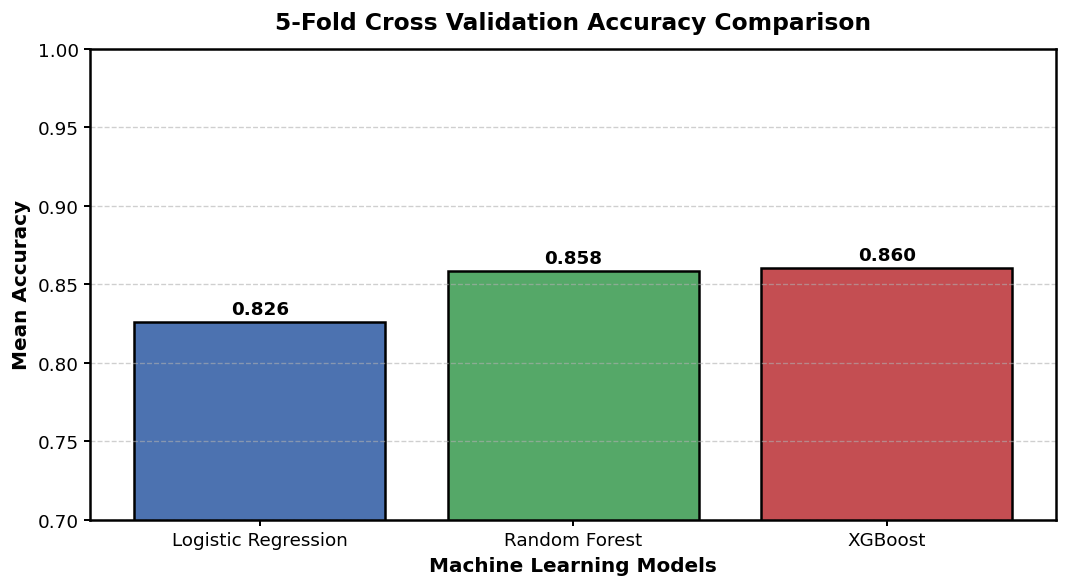

In [268]:
import matplotlib.pyplot as plt
import numpy as np

# Data
cv_results = [
    lr_cv.mean(),
    rf_cv.mean(),
    xgb_cv.mean()
]

models = ["Logistic Regression", "Random Forest", "XGBoost"]

# Academic color palette
colors = ["#4C72B0", "#55A868", "#C44E52"]

# Create figure
fig, ax = plt.subplots(figsize=(9,5), dpi=120)

bars = ax.bar(
    models,
    cv_results,
    color=colors,
    edgecolor="black",
    linewidth=1.5
)

# Titles and labels
ax.set_title(
    "5-Fold Cross Validation Accuracy Comparison",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel(
    "Machine Learning Models",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Mean Accuracy",
    fontsize=12,
    fontweight="bold"
)

# Grid styling
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Accuracy range
ax.set_ylim(0.7, 1.0)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha='center',
        fontsize=11,
        fontweight="bold"
    )

# ✅ FULL BOX AROUND GRAPH
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")

# Tick styling
ax.tick_params(axis='both', labelsize=11, width=1.2)

plt.tight_layout()
plt.show()